In [ ]:
%pip install -qqq torch torchvision setuptools scikit-learn
%pip install  --upgrade datasets -qqq accelerate hf-transfer transformers

# Understanding Learning Curves #
Now that we’ve learned how to implement fine-tuning using both the Trainer API and custom training loops, it’s crucial to understand how to interpret the results. Learning curves are invaluable tools that help you evaluate your model’s performance during training and identify potential issues before they reduce performance.

In this section, we’ll explore how to read and interpret accuracy and loss curves, understand what different curve shapes tell us about our model’s behavior, and learn how to address common training issues.

In [ ]:
from datasets import load_dataset

# Dataset id from huggingface.co/dataset
dataset_id = "burtenshaw/PleIAs_common_corpus_code_classification"

# Load raw dataset
dataset = load_dataset(dataset_id)

In [ ]:
print(len(dataset["train"]))
print(dataset["train"][0])

In [ ]:
from transformers import AutoTokenizer

# Model id to load the tokenizer
model_id = "answerdotai/ModernBERT-base"

# Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id)

# Tokenize helper function
def tokenize(batch):
    return tokenizer(batch['text'], padding=True, truncation=True, return_tensors="pt")

# Tokenize dataset
tokenized_dataset = dataset.map(tokenize, batched=True, remove_columns=["text"])

tokenized_dataset["train"].features.keys()
# dict_keys(['labels', 'input_ids', 'attention_mask'])


In [ ]:
from transformers import AutoModelForSequenceClassification

# Model id to load the tokenizer
model_id = "answerdotai/ModernBERT-base"

# Prepare model labels - useful for inference
labels = list(set(tokenized_dataset["train"]["labels"]))
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [ ]:
# Download the model from huggingface.co/models
model = AutoModelForSequenceClassification.from_pretrained(
    model_id, num_labels=num_labels, label2id=label2id, id2label=id2label,
)

In [ ]:
import numpy as np
from sklearn.metrics import f1_score

# Metric helper method
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    score = f1_score(
            labels, predictions, labels=labels, pos_label=1, average="weighted"
        )
    return {"f1": float(score) if score == 1 else score}


In [ ]:
from huggingface_hub import HfFolder
from transformers import Trainer, TrainingArguments

# Define training args
training_args = TrainingArguments(
    output_dir= "ModernBERT-code-classifier",
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=16,
    learning_rate=5e-5,
    num_train_epochs=5,
    bf16=True, # bfloat16 training
    optim="adamw_torch_fused", # improved optimizer
    # logging & evaluation strategies
    logging_strategy="steps",
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    # push to hub parameters
    push_to_hub=True,
    hub_strategy="every_save",
    hub_token=HfFolder.get_token(),
    report_to="wandb"
)



# Loss Curves #
The loss curve shows how the model’s error decreases over time. In a typical successful training run, you’ll see a curve similar to the one below:
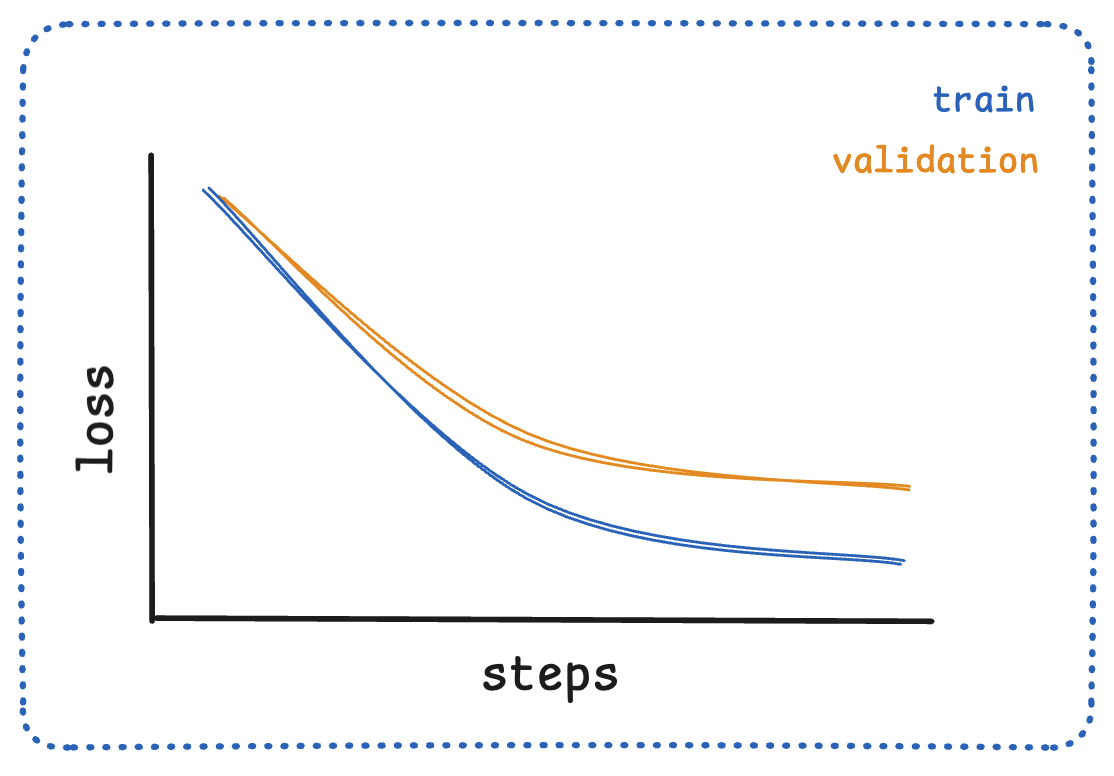
- High initial loss: The model starts without optimization, so predictions are initially poor

- Decreasing loss: As training progresses, the loss should generally decrease

- Convergence: Eventually, the loss stabilizes at a low value, indicating that the model has learned the patterns in the data

# Overfitting #
Overfitting occurs when the model learns too much from the training data and is unable to generalize to different data (represented by the validation set).
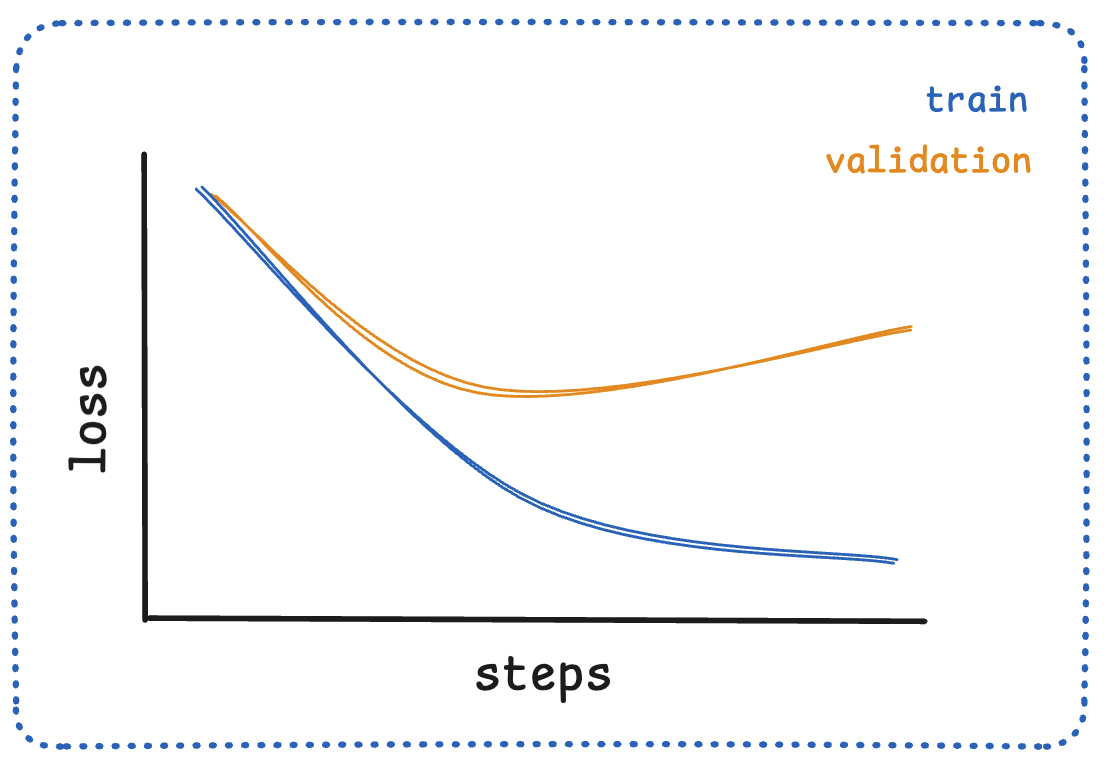

## Symptoms: ##
- Training loss continues to decrease while validation loss increases or plateaus
- Large gap between training and validation accuracy
- Training accuracy much higher than validation accuracy

## Solutions for overfitting: ##
- Regularization: Add dropout, weight decay, or other regularization techniques
- Early stopping: Stop training when validation performance stops improving
- Data augmentation: Increase training data diversity
- Reduce model complexity: Use a smaller model or fewer parameters

In [ ]:
limited_dataset = tokenized_dataset["train"].select(range(100))

# Create a Trainer instance
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=limited_dataset,
    eval_dataset=tokenized_dataset["test"],
    compute_metrics=compute_metrics,
)
trainer.train()

In [ ]:
# clear memory

import torch
torch.cuda.empty_cache()

del trainer
del model
del limited_dataset

# Underfitting #
Underfitting occurs when the model is too simple to capture the underlying patterns in the data. This can happen for several reasons:
- The model is too small or lacks capacity to learn the patterns
- The learning rate is too low, causing slow learning
- The dataset is too small or not representative of the problem
- The model is not properly regularized
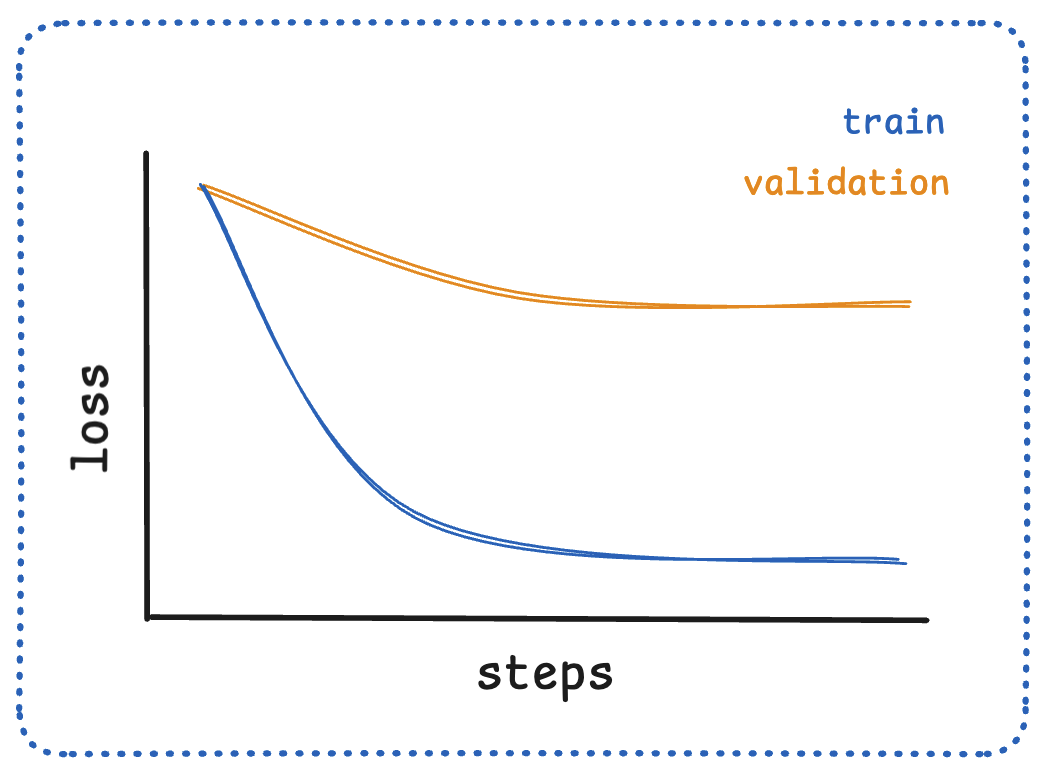

## Symptoms: ##
- Both training and validation loss remain high
- Model performance plateaus early in training
- Training accuracy is lower than expected

## Solutions for underfitting: ##
- Increase model capacity: Use a larger model or more parameters
- Train longer: Increase the number of epochs
- Adjust learning rate: Try different learning rates
- Check data quality: Ensure your data is properly preprocessed

In [ ]:
# define a low learning rate
training_args.learning_rate = 1e-7

# Create a Trainer instance
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=limited_dataset,
    eval_dataset=tokenized_dataset["test"],
    compute_metrics=compute_metrics,
)
trainer.train()

In [ ]:
# clear memory

import torch
torch.cuda.empty_cache()

del trainer
del model

# Erratic Learning Curves #
Erratic learning curves occur when the model is not learning effectively. This can happen for several reasons:
- The learning rate is too high, causing the model to overshoot the optimal parameters
- The batch size is too small, causing the model to learn slowly
- The model is not properly regularized, causing it to overfit to the training data
- The dataset is not properly preprocessed, causing the model to learn from noise
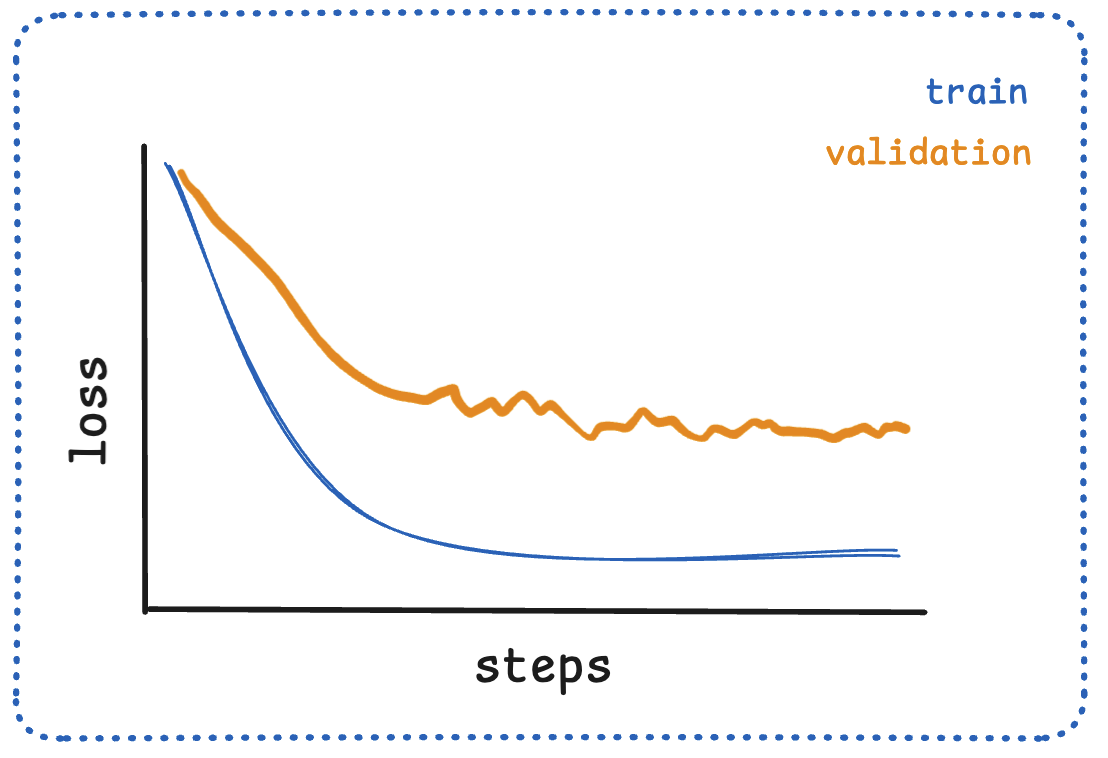

## Symptoms: ##
- Frequent fluctuations in loss or accuracy
- Curves show high variance or instability
- Performance oscillates without clear trend

Both training and validation curves show erratic behavior.

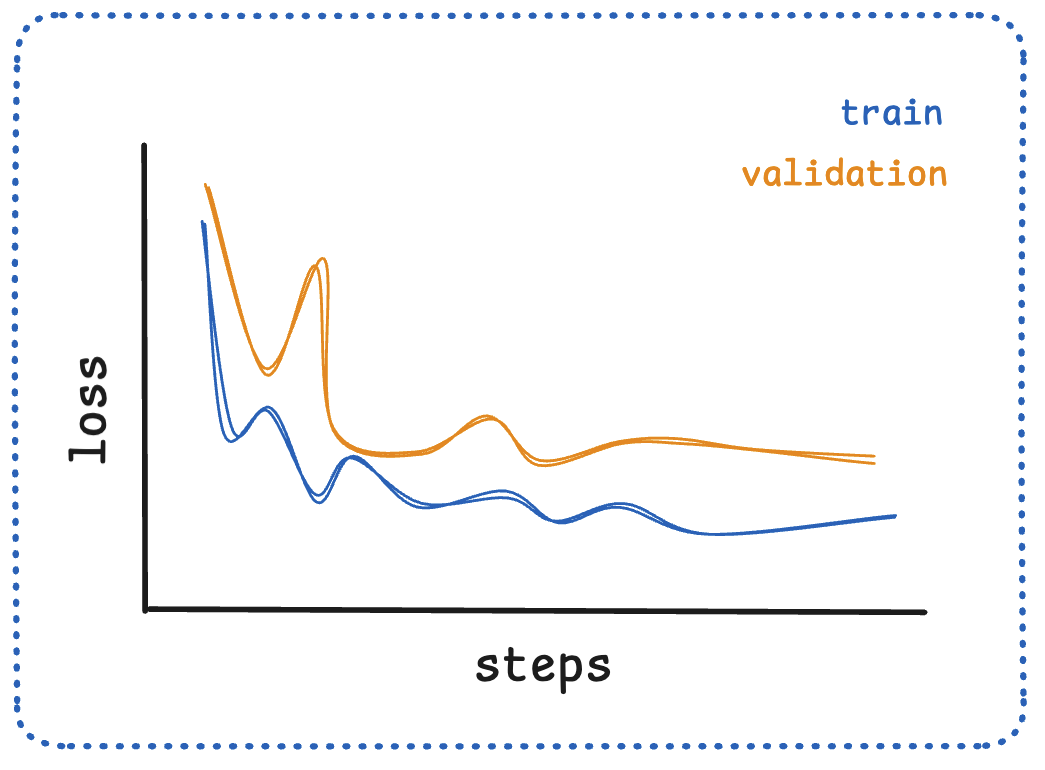

## Solutions for erratic curves: ##
- Lower learning rate: Reduce step size for more stable training
- Increase batch size: Larger batches provide more stable gradients
- Gradient clipping: Prevent exploding gradients
- Better data preprocessing: Ensure consistent data quality

# Just right! 🥣

In [ ]:
# define a valid learning rate
training_args.learning_rate = 5e-5

# Create a Trainer instance
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=limited_dataset,
    eval_dataset=tokenized_dataset["test"],
    compute_metrics=compute_metrics,
)
trainer.train()

# Inference

In [ ]:
from transformers import pipeline

# load model from huggingface.co/models using our repository id
classifier = pipeline(
    task="text-classification",
    model="argilla/ModernBERT-domain-classifier",
    device=0,
)

sample = """def add_numbers(a, b):
    return a + b"""

classifier(sample)
